# Project 48 — Experiment 6b: Merged Features (Fixed)
## PSG Signal Features + Questionnaire Features · Corrected Pipeline

---

### What went wrong in Experiment 6 and why

Three distinct problems caused the degradation in the original Experiment 6:

| Problem | What happened | Effect |
|---|---|---|
| **MI pre-filter was missing** | Pipeline went preprocessing → stability selection directly on 693 features. The MI filter step from Exp 5 was never ported into this notebook. | Stability selection received 693 features — far outside the regime it was designed for (p << n). It retained 95%+ (660+ features), which is not selection at all. |
| **Stability selection wrong regime** | ElasticNet bootstrap stability selection was designed for p << n settings (Meinshausen & Bühlmann 2010 paper). Here p=693, n=1,644 → p/n ≈ 0.42. At this ratio, ElasticNet keeps hundreds of non-zero coefficients per fit just to satisfy class balance, so almost every feature appears in every bootstrap. | 95% feature retention → models trained on essentially the full merged set → curse of dimensionality hit all linear and neural models, only tree ensembles survived. |
| **No early stopping on PyTorch MLP** | The MLP trained for all 60 epochs regardless of validation loss. For RLS, val loss was rising from epoch 20 onward — the model trained 40 epochs past its best checkpoint. | MLP_PyTorch val acc = 0.05 on RLS (predicting mostly positive), val acc = 0.93 on Insomnia (predicting all negative). Both collapsed. |

### The fix

1. **Two-stage feature selection**: MI pre-filter (≥ 0.002) first, then stability selection on the reduced set
2. **Expected feature counts after two-stage filter**: ~50–100 per target (appropriate for n=1,644)
3. **Early stopping on PyTorch MLP**: patience=10 on validation loss

## 1. Install & Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict,
    train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score
)
from sklearn.utils import resample
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

PyTorch 2.9.0+cu126 | CUDA: True
Device : cuda


## 2. Configuration

In [2]:
PSG_CSV_PATH   = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv'
QUEST_CSV_PATH = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/mesa-sleep-dataset-0.8.0.csv'

PSG_ID_COL    = 'nsrrid'
QUEST_ID_COL  = 'mesaid'

TARGET_COLUMNS     = ['Insomnia', 'RLS', 'apnea']
TARGET_LABELS      = {'Insomnia': 'Insomnia', 'RLS': 'RLS', 'apnea': 'Apnea'}
QUEST_TARGET_COLS  = ['insmnia5', 'rstlesslgs5', 'slpapnea5']

# PSG-specific preprocessing
HRV_RAW_COLS = ['HRV_SDNN_ms','HRV_RMSSD_ms','HRV_MeanRR_ms',
                'HRV_MeanHR_bpm','HRV_LF_ms2','HRV_HF_ms2','HRV_LF_HF']
SPARSE_HR_COLS     = ['MeanHR_W_bpm','MeanHR_N1_bpm','MeanHR_N2_bpm','MeanHR_N3_bpm','MeanHR_R_bpm']
DUPLICATE_PSG_COLS = ['EEG1_N2_Sigma_mean']
PSG_LOG_KEYWORDS   = ['_Power_','Intrusion','Hyperarousal','SWA_ratio','Desaturation_AUC','Segment_Duration_Variance']

# Questionnaire preprocessing
QUEST_MISSING_THRESHOLD = 0.4

# ── FIX 1: Two-stage feature selection ──────────────────────────────────────
# Stage 1 — MI pre-filter: applied BEFORE stability selection
#   Cuts 693 → ~120-180 features. This is the missing step from Exp 6.
MI_THRESHOLD = 0.002   # retains ~100-180 features from the merged set

# Stage 2 — ElasticNet bootstrap stability
#   Now operates in correct regime (~150 features, not 693)
N_BOOTSTRAPS        = 30
STABILITY_THRESHOLD = 0.5
STABILITY_C         = 0.05

# Model / CV
CV_FOLDS     = 3
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# ── FIX 3: Early stopping for PyTorch MLP ────────────────────────────────────
DL_EPOCHS     = 100    # max epochs — early stopping will terminate before this
DL_PATIENCE   = 10     # stop if val loss doesn't improve for 10 consecutive epochs
DL_BATCH_SIZE = 64
DL_LR         = 1e-3

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250',   'axes.labelcolor': '#c9cde0',
    'xtick.color': '#8b90a8',      'ytick.color': '#8b90a8',
    'text.color': '#c9cde0',       'grid.color': '#2e3250',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'monospace',
})
MODEL_COLORS = {
    'LogisticReg' : '#4fc3f7',
    'RandomForest': '#81c784',
    'XGBoost'     : '#ffb74d',
    'LinearSVM'   : '#ce93d8',
    'MLP_sklearn' : '#f48fb1',
    'MLP_PyTorch' : '#ff6e6e',
}
BASELINES = {
    'Exp4_Questionnaire': {'Apnea': 0.7843, 'Insomnia': 0.3881, 'RLS': 0.1553},
    'Exp5_PSG':           {'Apnea': 0.1825, 'Insomnia': 0.1304, 'RLS': 0.1818},
    'Exp6_Merged_broken': {'Apnea': 0.7843, 'Insomnia': 0.2128, 'RLS': 0.1148},
}

print('✅ Config loaded')
print(f'   MI pre-filter threshold : {MI_THRESHOLD}  ← NEW: was missing in Exp 6')
print(f'   Stability bootstraps    : {N_BOOTSTRAPS}')
print(f'   Stability threshold     : {STABILITY_THRESHOLD}')
print(f'   DL early stopping patience: {DL_PATIENCE}  ← NEW: was missing in Exp 6')

✅ Config loaded
   MI pre-filter threshold : 0.002  ← NEW: was missing in Exp 6
   Stability bootstraps    : 30
   Stability threshold     : 0.5
   DL early stopping patience: 10  ← NEW: was missing in Exp 6


## 3. Load & Merge

In [3]:
psg   = pd.read_csv(PSG_CSV_PATH)
quest = pd.read_csv(QUEST_CSV_PATH)
print(f'PSG:           {psg.shape[0]} rows × {psg.shape[1]} cols')
print(f'Questionnaire: {quest.shape[0]} rows × {quest.shape[1]} cols')

quest = quest.drop(columns=[c for c in QUEST_TARGET_COLS if c in quest.columns])

merged = psg.merge(
    quest,
    left_on=PSG_ID_COL, right_on=QUEST_ID_COL,
    how='inner', suffixes=('_psg', '_q')
)
merged = merged.drop(columns=[c for c in [PSG_ID_COL, QUEST_ID_COL] if c in merged.columns])

print(f'\nMerged shape: {merged.shape[0]} rows × {merged.shape[1]} cols')
print(f'Subjects lost in inner join: {psg.shape[0] - merged.shape[0]}')
for t in TARGET_COLUMNS:
    pos = merged[t].sum()
    print(f'  {TARGET_LABELS[t]:10s}: pos={pos} ({pos/len(merged)*100:.1f}%)')

psg_original_cols = set(pd.read_csv(PSG_CSV_PATH, nrows=0).columns.tolist())

PSG:           2056 rows × 136 cols
Questionnaire: 2237 rows × 626 cols

Merged shape: 2056 rows × 757 cols
Subjects lost in inner join: 0
  Insomnia  : pos=130 (6.3%)
  RLS       : pos=92 (4.5%)
  Apnea     : pos=156 (7.6%)


## 4. Preprocessing

In [4]:
def preprocess_merged(df, target):
    drop_cols = TARGET_COLUMNS + SPARSE_HR_COLS + DUPLICATE_PSG_COLS
    X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
    y = df[target].copy()

    # Drop questionnaire cols with >40% missing
    quest_cols    = [c for c in X.columns if c not in psg_original_cols]
    missing_rate  = X[quest_cols].isna().mean()
    high_missing  = missing_rate[missing_rate > QUEST_MISSING_THRESHOLD].index.tolist()
    X = X.drop(columns=high_missing)
    print(f'  Dropped {len(high_missing)} questionnaire cols with >{QUEST_MISSING_THRESHOLD*100:.0f}% missing')

    # Handle non-numeric
    for col in X.columns:
        if X[col].dtype == 'object':
            try:
                t = pd.to_datetime(X[col], format='%H:%M:%S', errors='raise')
                X[col] = t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second
            except:
                try:
                    X[col] = pd.to_numeric(X[col])
                except:
                    X[col] = X[col].astype('category').cat.codes.replace(-1, np.nan)

    # Fix HRV zeros
    for col in [c for c in HRV_RAW_COLS if c in X.columns]:
        X[col] = X[col].replace(0, np.nan).fillna(X[col].median())

    # Log1p for skewed PSG features
    for col in X.columns:
        if col in HRV_RAW_COLS or any(kw in col for kw in PSG_LOG_KEYWORDS):
            X[col] = np.log1p(X[col].clip(lower=0))

    # Impute + scale
    feat_names = X.columns.tolist()
    X_scaled   = RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(X))

    print(f'  Features after preprocessing: {len(feat_names)}')
    print(f'  Missing values: {np.isnan(X_scaled).sum()}')
    return X_scaled, y, feat_names


print('✅ Preprocessing ready')

✅ Preprocessing ready


## 5. Two-Stage Feature Selection  ← Key Fix

**Stage 1 — MI pre-filter** cuts 693 → ~120–180 features. This step was completely missing from Experiment 6.

**Stage 2 — ElasticNet bootstrap stability** now operates on a manageable feature count (p/n < 0.15 instead of 0.42), which is the regime it was designed for.

In [5]:
def mi_prefilter(X, y, feature_names, threshold=MI_THRESHOLD):
    """
    Stage 1: Hard mutual information threshold.
    Drops features with MI < threshold — removes the true noise before
    stability selection even runs.
    """
    print(f'  Stage 1 — MI pre-filter (threshold={threshold})')
    mi      = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    mask    = mi >= threshold
    keep    = [f for f, m in zip(feature_names, mask) if m]
    mi_df   = pd.Series(mi, index=feature_names).sort_values(ascending=False)

    print(f'  {len(feature_names)} → {len(keep)} features '
          f'(dropped {len(feature_names)-len(keep)} with MI < {threshold})')
    print(f'  p/n ratio after MI filter: {len(keep)/len(y):.3f}  '
          f'(was {len(feature_names)/len(y):.3f} — stability selection needs p/n < 0.15)')
    print(f'  Top 15 features by MI:')
    for feat, val in mi_df.head(15).items():
        tag = '[PSG]' if feat in psg_original_cols else '[Q]  '
        print(f'    {tag} {feat:<45} {val:.5f}')
    return X[:, mask], keep, mi_df


def stability_selection(X, y, feature_names):
    """
    Stage 2: ElasticNet bootstrap stability selection.
    Now operates on the MI-filtered feature set (~120-180 features).
    """
    print(f'  Stage 2 — ElasticNet bootstrap (N={N_BOOTSTRAPS}, '
          f'threshold={STABILITY_THRESHOLD}, C={STABILITY_C})')
    t0     = time.time()
    counts = Counter()
    model  = LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=0.5, C=STABILITY_C,
        class_weight='balanced',
        max_iter=5000, tol=1e-3,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    for i in range(N_BOOTSTRAPS):
        Xb, yb = resample(X, y, stratify=y, random_state=RANDOM_STATE + i)
        model.fit(Xb, yb)
        counts.update(np.array(feature_names)[model.coef_.ravel() != 0])
        if (i + 1) % 10 == 0:
            print(f'     Bootstrap {i+1}/{N_BOOTSTRAPS}  ({time.time()-t0:.0f}s)')

    min_count = int(STABILITY_THRESHOLD * N_BOOTSTRAPS)
    stable    = [f for f, c in counts.items() if c >= min_count]
    freq_df   = pd.DataFrame(
        [(f, c, round(c/N_BOOTSTRAPS, 3)) for f, c in counts.most_common()],
        columns=['feature', 'count', 'frequency']
    )
    print(f'  {len(feature_names)} → {len(stable)} stable features in {time.time()-t0:.0f}s '
          f'(retention: {len(stable)/len(feature_names)*100:.1f}%)')
    return stable, freq_df


print('✅ Two-stage feature selection ready')

✅ Two-stage feature selection ready


## 6. Model Zoo

In [6]:
def get_models(pos_weight=1.0):
    return {
        'LogisticReg': LogisticRegression(
            penalty='elasticnet', solver='saga',
            l1_ratio=0.5, C=0.1,
            class_weight='balanced',
            max_iter=10000, tol=1e-3,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=8,
            class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric='logloss', verbosity=0,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(C=0.1, class_weight='balanced',
                      max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
            cv=3
        ),
        'MLP_sklearn': MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu',
            max_iter=300, early_stopping=True, validation_fraction=0.15,
            random_state=RANDOM_STATE
        ),
    }

print('✅ Model zoo ready')

✅ Model zoo ready


## 7. PyTorch Deep MLP — with Early Stopping  ← Key Fix

In [7]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_deep_mlp(X_tr, y_tr, X_val, y_val):
    """
    Trains with early stopping (patience=DL_PATIENCE on val loss).
    Returns best-checkpoint model, not last-epoch model.
    """
    X_t = torch.tensor(X_tr,         dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_tr.values,  dtype=torch.float32).to(DEVICE)
    X_v = torch.tensor(X_val,        dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=DL_BATCH_SIZE, shuffle=True)
    neg, pos  = (y_tr == 0).sum(), (y_tr == 1).sum()
    pos_w     = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(DEVICE)
    model     = DeepMLP(X_tr.shape[1]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.AdamW(model.parameters(), lr=DL_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DL_EPOCHS)

    tr_losses, vl_losses, tr_accs, vl_accs = [], [], [], []

    # Early stopping state
    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0
    best_epoch     = 0

    for epoch in range(DL_EPOCHS):
        model.train()
        ep_loss = ep_correct = ep_total = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            ep_loss    += loss.item() * len(yb)
            ep_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            ep_total   += len(yb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            v_logits = model(X_v)
            v_loss   = criterion(v_logits, y_v).item()
            v_acc    = ((torch.sigmoid(v_logits) > 0.5).float() == y_v).float().mean().item()

        tr_losses.append(ep_loss / ep_total)
        vl_losses.append(v_loss)
        tr_accs.append(ep_correct / ep_total)
        vl_accs.append(v_acc)

        # Early stopping check
        if v_loss < best_val_loss - 1e-4:
            best_val_loss  = v_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            best_epoch     = epoch + 1
        else:
            patience_count += 1

        if (epoch + 1) % 20 == 0:
            print(f'    Epoch [{epoch+1:>3}/{DL_EPOCHS}]  '
                  f'Train loss={tr_losses[-1]:.4f} acc={tr_accs[-1]:.4f}  '
                  f'Val loss={vl_losses[-1]:.4f} acc={vl_accs[-1]:.4f}  '
                  f'patience={patience_count}/{DL_PATIENCE}')

        if patience_count >= DL_PATIENCE:
            print(f'    Early stopping at epoch {epoch+1} '
                  f'(best epoch={best_epoch}, best val_loss={best_val_loss:.4f})')
            break

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'    Restored best checkpoint from epoch {best_epoch}')

    return model, tr_losses, vl_losses, tr_accs, vl_accs


def dl_proba(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(
            model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        ).cpu().numpy()


print('✅ PyTorch DeepMLP ready (with early stopping, patience={DL_PATIENCE})')

✅ PyTorch DeepMLP ready (with early stopping, patience={DL_PATIENCE})


## 8. Evaluation & Plotting Utilities

In [8]:
def tune_threshold(y_true, probs):
    prec, rec, thr = precision_recall_curve(y_true, probs)
    return thr[np.argmax(2 * prec * rec / (prec + rec + 1e-9))]


def plot_confusion_matrices(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor('#0f1117')
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    for ax, data, fmt, t in zip(
        axes, [cm, cm_pct], ['d', '.1f'],
        [f'{title} — Count', f'{title} — Row-Normalised (%)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    linewidths=0.5, linecolor='#2e3250',
                    annot_kws={'size': 13, 'weight': 'bold'})
        ax.set_title(t, pad=12, color='#c9cde0')
        ax.set_xlabel('Predicted', color='#8b90a8')
        ax.set_ylabel('Actual',    color='#8b90a8')
        ax.set_xticklabels(['Negative', 'Positive'], rotation=0)
        ax.set_yticklabels(['Negative', 'Positive'], rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc(results, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['probs'])
        ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name} (AUC={auc(fpr,tpr):.3f})')
    ax.set_title(f'{title} — ROC', pad=12); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.3); ax.grid(True)
    plt.tight_layout(); plt.show()


def plot_pr(results, title, baseline):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.axhline(y=baseline, color='#555', lw=1, ls='--', label=f'No-skill ({baseline:.3f})')
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(res['y_true'], res['probs'])
        ap = average_precision_score(res['y_true'], res['probs'])
        ax.step(rec, prec, where='post', lw=2, color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name} (AP={ap:.3f})')
    ax.set_title(f'{title} — PR', pad=12); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.legend(loc='upper right', fontsize=8, framealpha=0.3); ax.grid(True)
    plt.tight_layout(); plt.show()


def _diagnose(ax, gap):
    if gap > 0.15:   txt, col = f'Overfitting  (gap={gap:.2f})', '#ff6e6e'
    elif gap < -0.05: txt, col = f'Underfitting (val > train)', '#ffb74d'
    else:            txt, col = f'Good fit     (gap={gap:.2f})', '#81c784'
    ax.text(0.02, 0.04, txt, transform=ax.transAxes,
            color=col, fontsize=9, fontweight='bold')


def plot_dl_curves(tr_l, vl_l, tr_a, vl_a, label):
    epochs = range(1, len(tr_l) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0f1117')
    fig.suptitle(f'{label} · MLP_PyTorch — Training Diagnostics (with early stopping)',
                 color='#c9cde0', fontsize=12)
    for ax, tr, vl, ylabel, metric in zip(
        axes, [tr_l, tr_a], [vl_l, vl_a], ['BCE Loss', 'Accuracy'], ['Loss', 'Acc']):
        ax.plot(epochs, tr, color='#4fc3f7', lw=2, label=f'Train {metric}')
        ax.plot(epochs, vl, color='#ff6e6e', lw=2, label=f'Val {metric}')
        ax.set_title(f'{ylabel} per Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, framealpha=0.3); ax.grid(True)
        gap = (vl[-1] - tr[-1]) if metric == 'Loss' else (tr[-1] - vl[-1])
        _diagnose(ax, gap)
    plt.tight_layout(); plt.show()


def plot_mi_feature_sources(stable_features, mi_df, label):
    """Bar chart showing stable features coloured by source (PSG vs questionnaire)."""
    psg_stable   = [f for f in stable_features if f in psg_original_cols]
    quest_stable = [f for f in stable_features if f not in psg_original_cols]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.patch.set_facecolor('#0f1117')

    # Source breakdown
    ax = axes[0]
    ax.barh(['PSG Signal', 'Questionnaire'], [len(psg_stable), len(quest_stable)],
            color=['#4fc3f7', '#ffb74d'], height=0.5)
    ax.set_title(f'{label} — Stable features by source', pad=10)
    ax.set_xlabel('Feature count')
    for i, v in enumerate([len(psg_stable), len(quest_stable)]):
        ax.text(v + 0.2, i, str(v), va='center', fontsize=12, fontweight='bold')
    ax.grid(True, axis='x')

    # Top 15 stable features by MI
    ax = axes[1]
    top = mi_df[mi_df.index.isin(stable_features)].head(15)
    colors = ['#4fc3f7' if f in psg_original_cols else '#ffb74d' for f in top.index[::-1]]
    ax.barh(range(len(top)), top.values[::-1], color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f[-30:] for f in top.index[::-1]], fontsize=9)
    ax.set_title(f'{label} — Top 15 stable features by MI', pad=10)
    ax.set_xlabel('MI Score')
    ax.grid(True, axis='x')

    plt.tight_layout(); plt.show()
    print(f'  PSG features: {len(psg_stable)}  |  Questionnaire features: {len(quest_stable)}')


print('✅ Plotting utilities ready')

✅ Plotting utilities ready


## 9. Load Data

In [9]:
psg   = pd.read_csv(PSG_CSV_PATH)
quest = pd.read_csv(QUEST_CSV_PATH)
quest = quest.drop(columns=[c for c in QUEST_TARGET_COLS if c in quest.columns])
merged = psg.merge(quest, left_on=PSG_ID_COL, right_on=QUEST_ID_COL,
                   how='inner', suffixes=('_psg', '_q'))
merged = merged.drop(columns=[c for c in [PSG_ID_COL, QUEST_ID_COL] if c in merged.columns])
psg_original_cols = set(pd.read_csv(PSG_CSV_PATH, nrows=0).columns.tolist())
print(f'Merged: {merged.shape[0]} rows × {merged.shape[1]} cols')
for t in TARGET_COLUMNS:
    pos = merged[t].sum()
    print(f'  {TARGET_LABELS[t]:10s}: pos={pos} ({pos/len(merged)*100:.1f}%)')

Merged: 2056 rows × 757 cols
  Insomnia  : pos=130 (6.3%)
  RLS       : pos=92 (4.5%)
  Apnea     : pos=156 (7.6%)


## 10. Full Pipeline — Per Target


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  INSOMNIA (Insomnia)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/8] Preprocessing...
  Dropped 55 questionnaire cols with >40% missing
  Features after preprocessing: 693
  Missing values: 0
  Samples: 2056  |  Pos: 130 (6.3%)

[2/8] Stage 1 — MI pre-filter...
  Stage 1 — MI pre-filter (threshold=0.002)
  693 → 233 features (dropped 460 with MI < 0.002)
  p/n ratio after MI filter: 0.113  (was 0.337 — stability selection needs p/n < 0.15)
  Top 15 features by MI:
    [Q]   whiirs5c                                      0.03246
    [Q]   trbleslpng5                                   0.02875
    [Q]   irritable5                                    0.02055
    [Q]   nightsinvalid5                                0.01822
    [Q]   typicalslp5                                   0.01738
    [Q]   slpngpills5                                   0.01514
    [Q]   wakeup5                                  

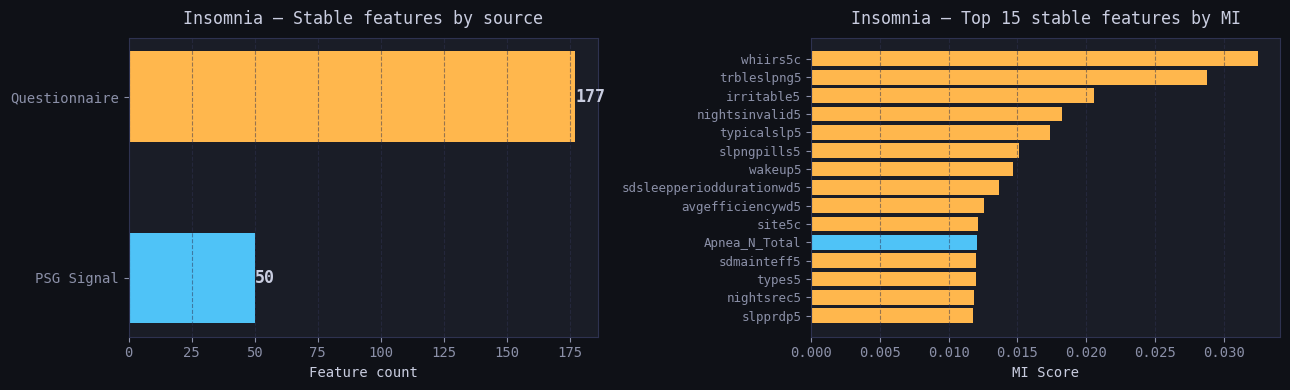

  PSG features: 50  |  Questionnaire features: 177

  Train=1644 Test=412 pos_rate=0.063 pos_weight=14.8

[5/8] Training sklearn models...
  ► LogisticReg... F1=0.098  AUROC=0.443  AP=0.059  (13s)
  ► RandomForest... F1=0.150  AUROC=0.679  AP=0.162  (5s)
  ► XGBoost... F1=0.179  AUROC=0.711  AP=0.188  (6s)
  ► LinearSVM... 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


F1=0.119  AUROC=0.474  AP=0.061  (16s)
  ► MLP_sklearn... F1=0.049  AUROC=0.504  AP=0.068  (1s)

  ► MLP_PyTorch (max=100 epochs, patience=10)...
    Early stopping at epoch 11 (best epoch=1, best val_loss=1.2919)
    Restored best checkpoint from epoch 1
  F1=0.132  AUROC=0.568  AP=0.111  (6s)

[6/8] Classification Reports — Insomnia

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9249    0.4145    0.5725       386
    Positive     0.0544    0.5000    0.0981        26

    accuracy                         0.4199       412
   macro avg     0.4896    0.4573    0.3353       412
weighted avg     0.8699    0.4199    0.5425       412


  ▸ RandomForest
              precision    recall  f1-score   support

    Negative     0.9441    0.8756    0.9086       386
    Positive     0.1111    0.2308    0.1500        26

    accuracy                         0.8350       412
   macro avg     0.5276    0.5532    0.5293       412
weighted avg     0.8916    0.

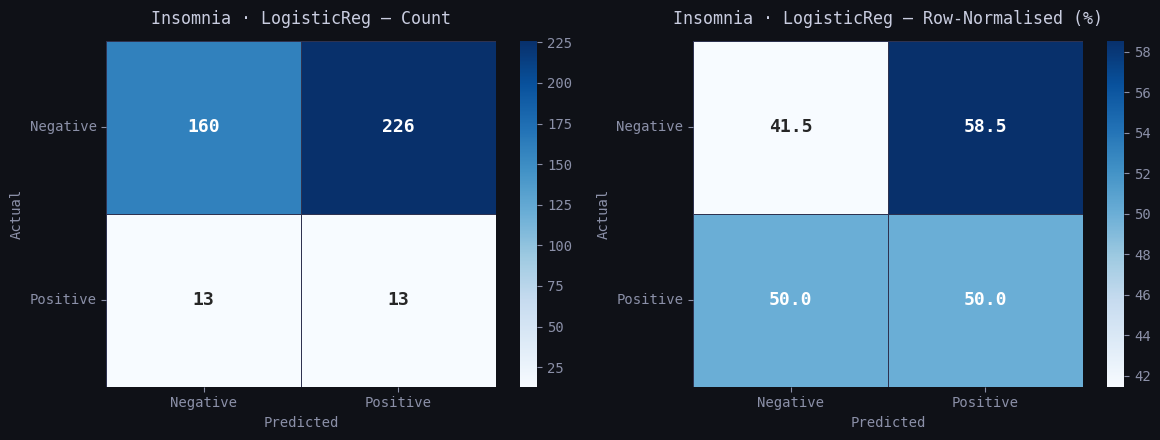

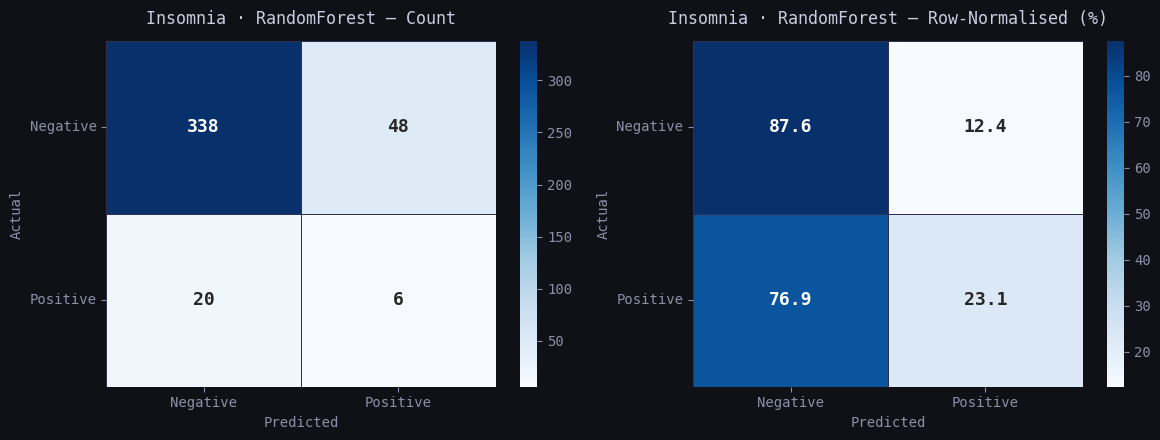

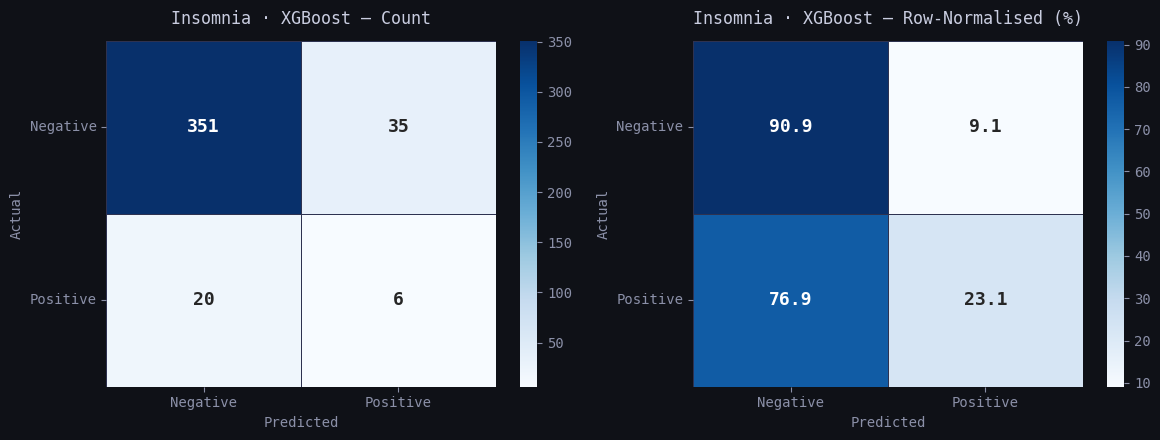

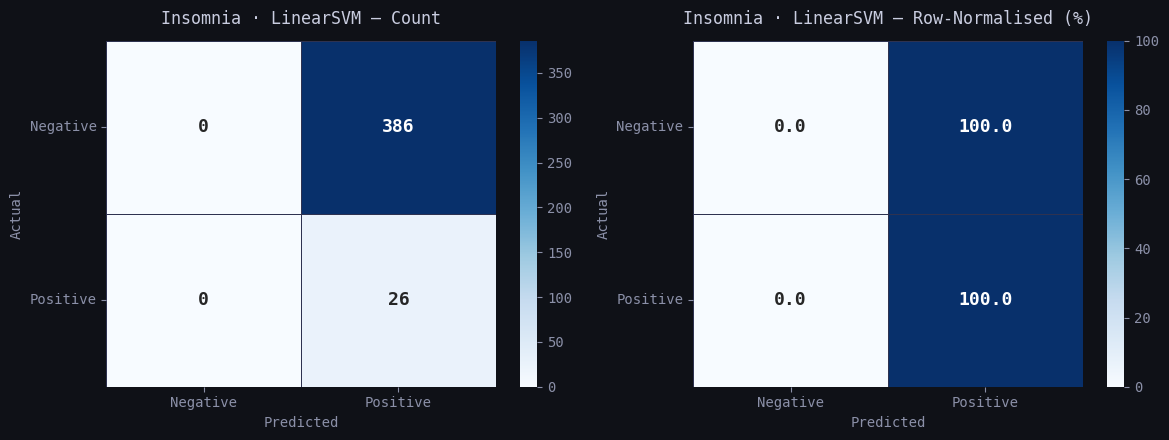

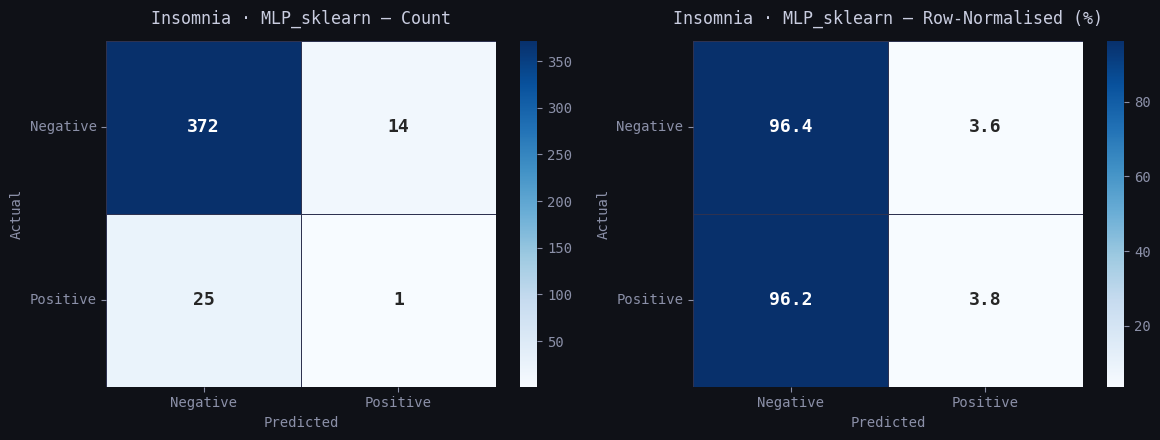

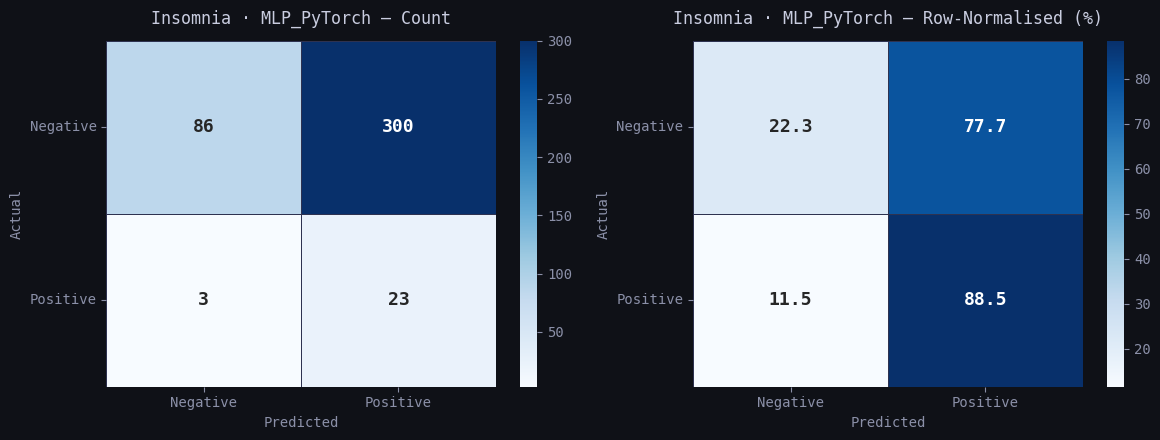

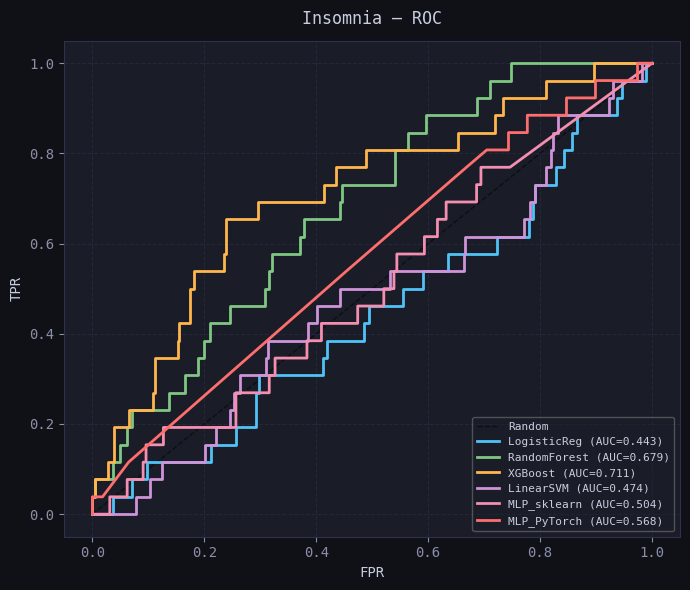

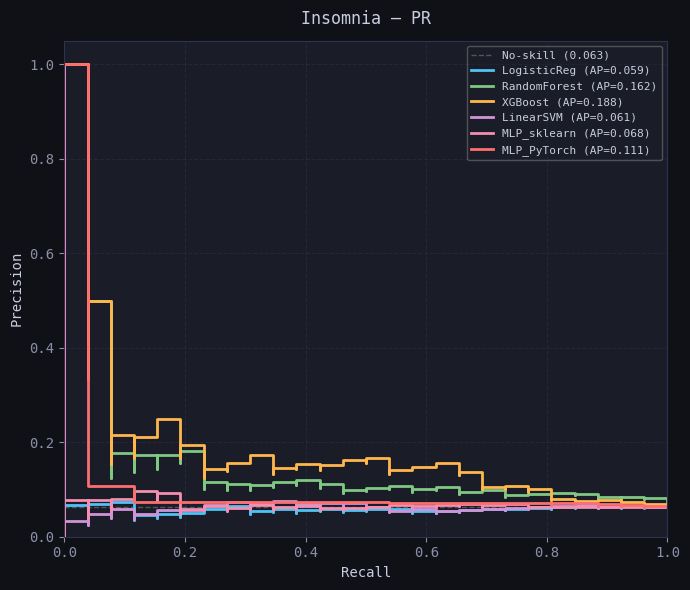


[8/8] DL Training Curves — Insomnia


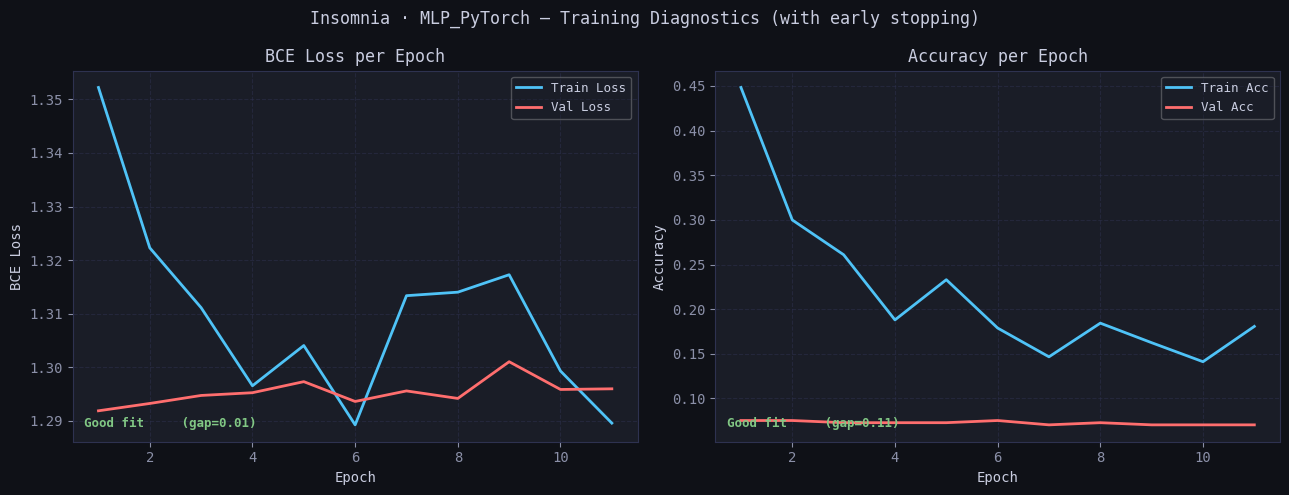


  ⏱ Insomnia total: 4.1 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  RLS (RLS)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/8] Preprocessing...
  Dropped 55 questionnaire cols with >40% missing
  Features after preprocessing: 693
  Missing values: 0
  Samples: 2056  |  Pos: 92 (4.5%)

[2/8] Stage 1 — MI pre-filter...
  Stage 1 — MI pre-filter (threshold=0.002)
  693 → 222 features (dropped 471 with MI < 0.002)
  p/n ratio after MI filter: 0.108  (was 0.337 — stability selection needs p/n < 0.15)
  Top 15 features by MI:
    [Q]   legsdscmfrt5                                  0.01418
    [PSG] EEG1_N1_Delta_Power_std                       0.01062
    [Q]   limbdur5                                      0.01032
    [Q]   havgdur5                                      0.01023
    [PSG] PLM_N                                         0.01018
    [Q]   que15                                         0.01012
    [Q]   avgwasonw5             

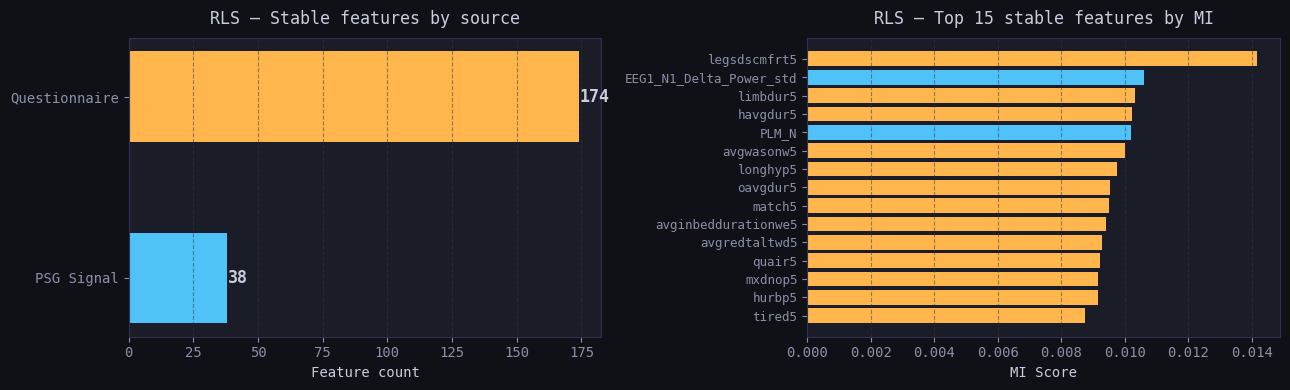

  PSG features: 38  |  Questionnaire features: 174

  Train=1644 Test=412 pos_rate=0.045 pos_weight=21.2

[5/8] Training sklearn models...
  ► LogisticReg... F1=0.055  AUROC=0.532  AP=0.059  (8s)
  ► RandomForest... F1=0.133  AUROC=0.707  AP=0.087  (3s)
  ► XGBoost... F1=0.145  AUROC=0.723  AP=0.089  (4s)
  ► LinearSVM... F1=0.057  AUROC=0.507  AP=0.059  (1s)
  ► MLP_sklearn... F1=0.084  AUROC=0.564  AP=0.071  (1s)

  ► MLP_PyTorch (max=100 epochs, patience=10)...
    Early stopping at epoch 11 (best epoch=1, best val_loss=1.3028)
    Restored best checkpoint from epoch 1
  F1=0.109  AUROC=0.459  AP=0.071  (1s)

[6/8] Classification Reports — RLS

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9533    0.7766    0.8559       394
    Positive     0.0330    0.1667    0.0550        18

    accuracy                         0.7500       412
   macro avg     0.4931    0.4717    0.4555       412
weighted avg     0.9131    0.7500    0.8210       412




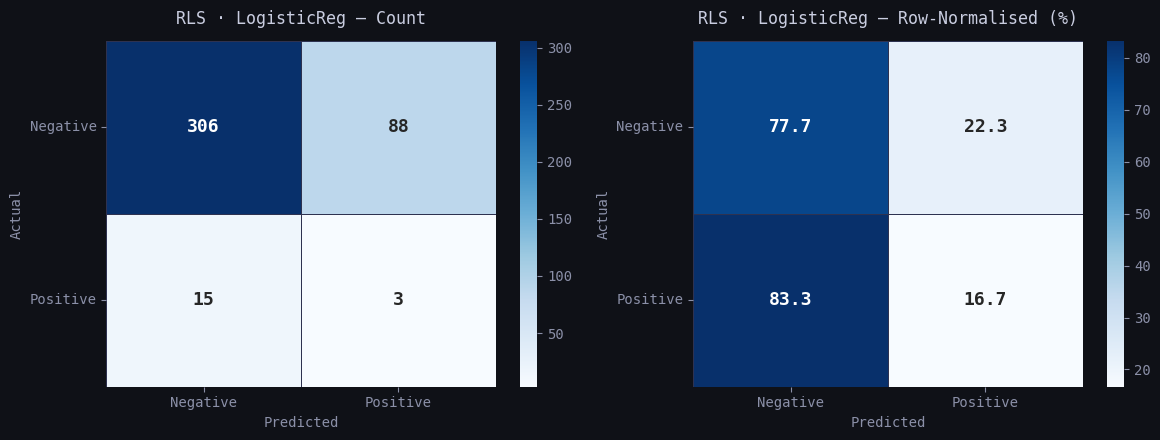

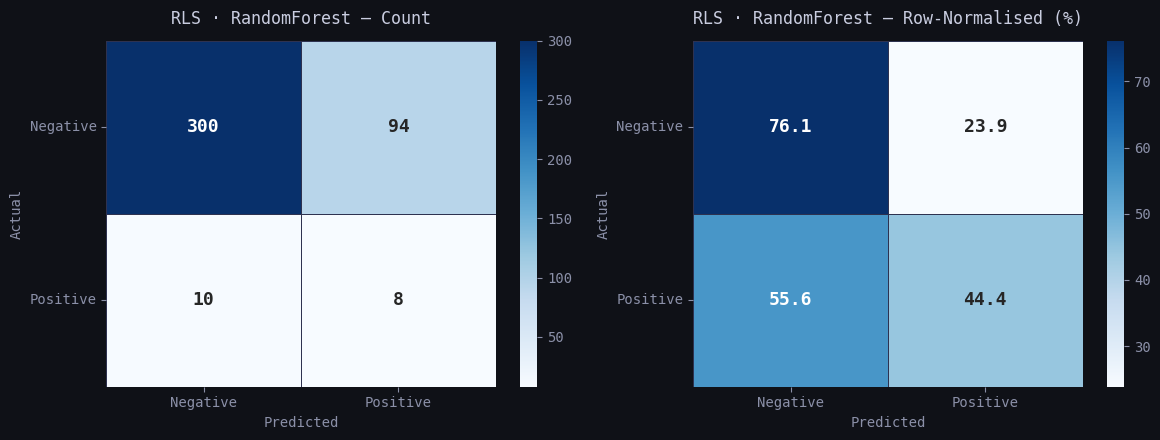

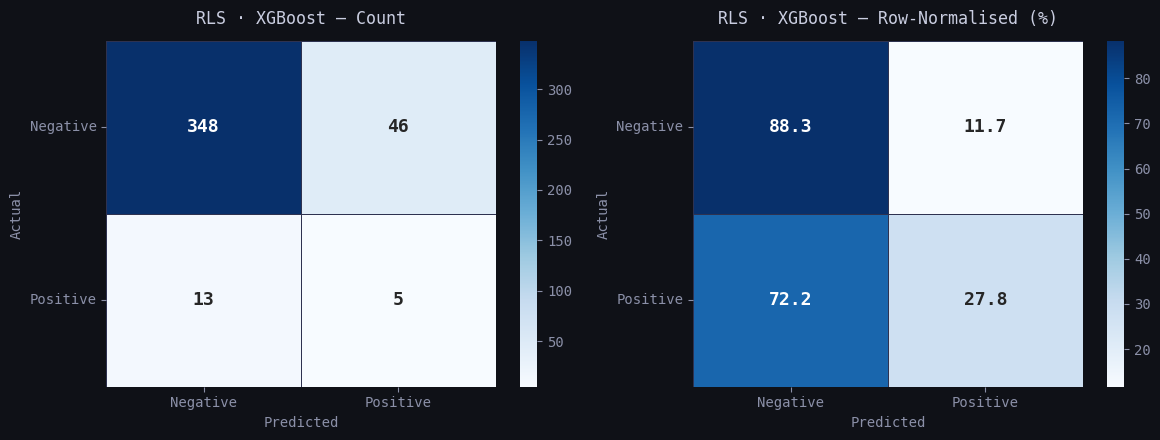

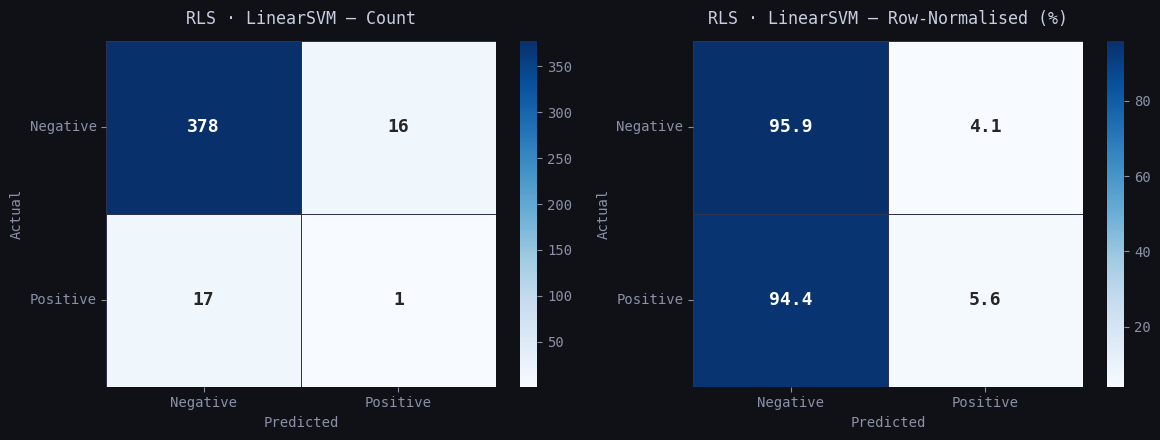

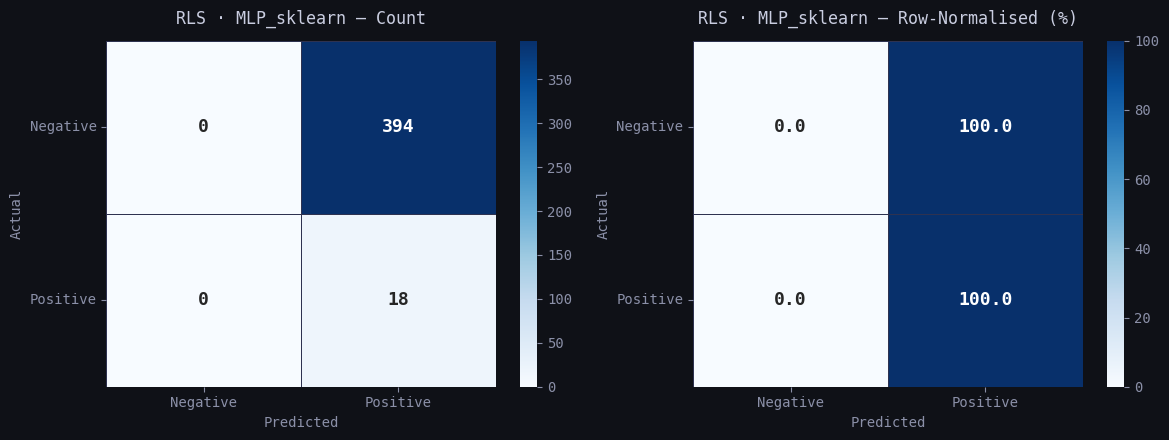

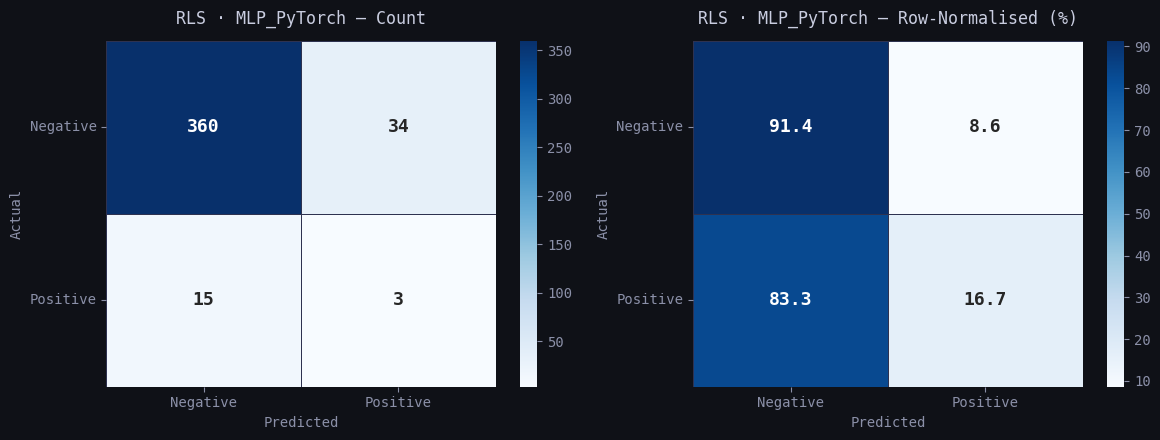

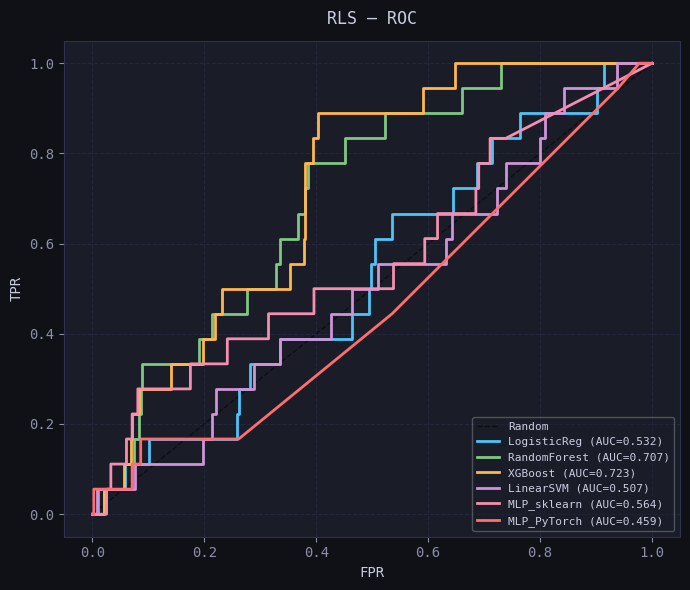

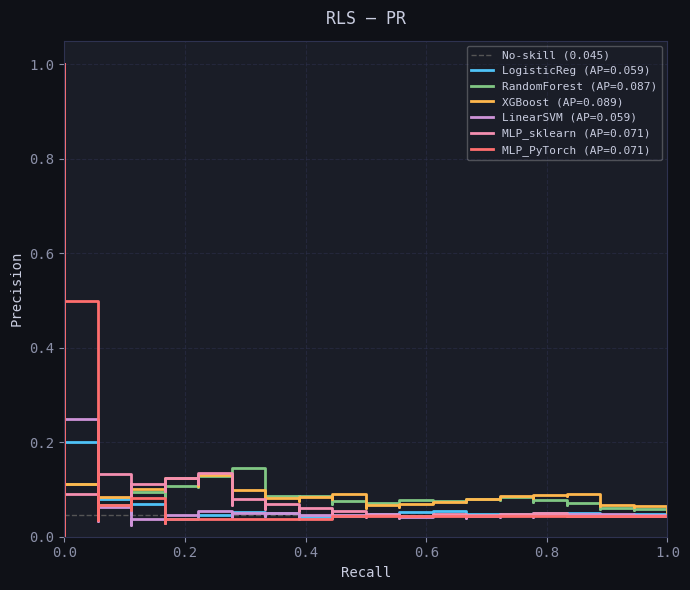


[8/8] DL Training Curves — RLS


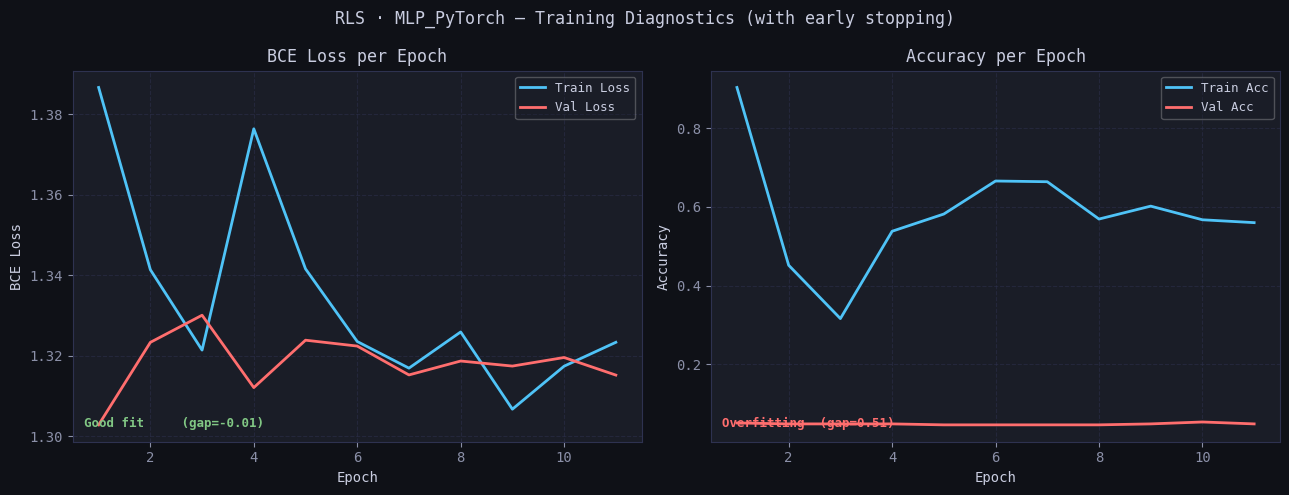


  ⏱ RLS total: 3.0 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  APNEA (apnea)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/8] Preprocessing...
  Dropped 55 questionnaire cols with >40% missing
  Features after preprocessing: 693
  Missing values: 0
  Samples: 2056  |  Pos: 156 (7.6%)

[2/8] Stage 1 — MI pre-filter...
  Stage 1 — MI pre-filter (threshold=0.002)
  693 → 303 features (dropped 390 with MI < 0.002)
  p/n ratio after MI filter: 0.147  (was 0.337 — stability selection needs p/n < 0.15)
  Top 15 features by MI:
    [Q]   cpap5                                         0.12978
    [PSG] Apnea_N_Total                                 0.02005
    [Q]   dssao905                                      0.01964
    [Q]   phbslp5                                       0.01842
    [Q]   sdmainteff5                                   0.01817
    [Q]   ahi_c0h3a                                     0.01772
    [Q]   ahi_c0h4               

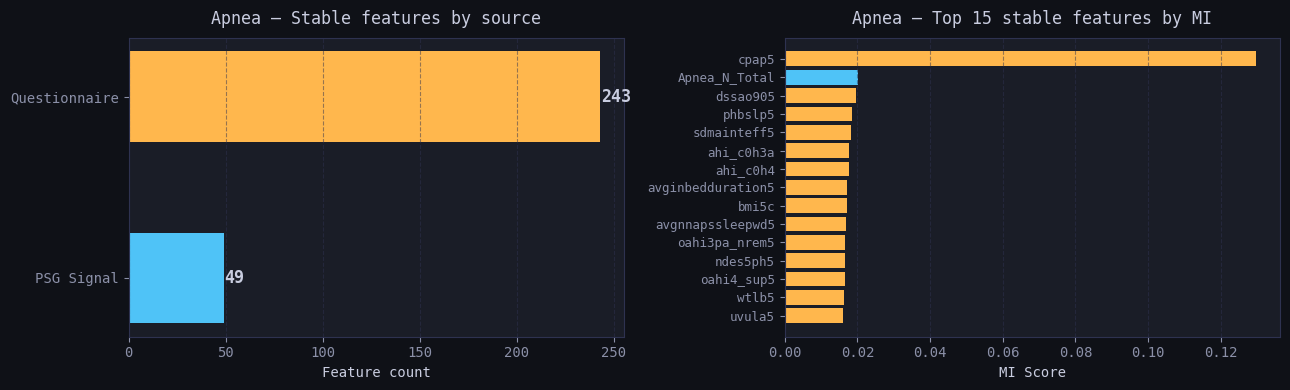

  PSG features: 49  |  Questionnaire features: 243

  Train=1644 Test=412 pos_rate=0.076 pos_weight=12.2

[5/8] Training sklearn models...
  ► LogisticReg... F1=0.155  AUROC=0.672  AP=0.128  (17s)
  ► RandomForest... F1=0.638  AUROC=0.861  AP=0.695  (5s)
  ► XGBoost... F1=0.784  AUROC=0.872  AP=0.743  (6s)
  ► LinearSVM... F1=0.043  AUROC=0.600  AP=0.100  (27s)
  ► MLP_sklearn... F1=0.140  AUROC=0.522  AP=0.100  (1s)

  ► MLP_PyTorch (max=100 epochs, patience=10)...
    Early stopping at epoch 12 (best epoch=2, best val_loss=1.2693)
    Restored best checkpoint from epoch 2
  F1=0.175  AUROC=0.584  AP=0.090  (1s)

[6/8] Classification Reports — Apnea

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     1.0000    0.1155    0.2071       381
    Positive     0.0842    1.0000    0.1554        31

    accuracy                         0.1820       412
   macro avg     0.5421    0.5577    0.1812       412
weighted avg     0.9311    0.1820    0.2032       41

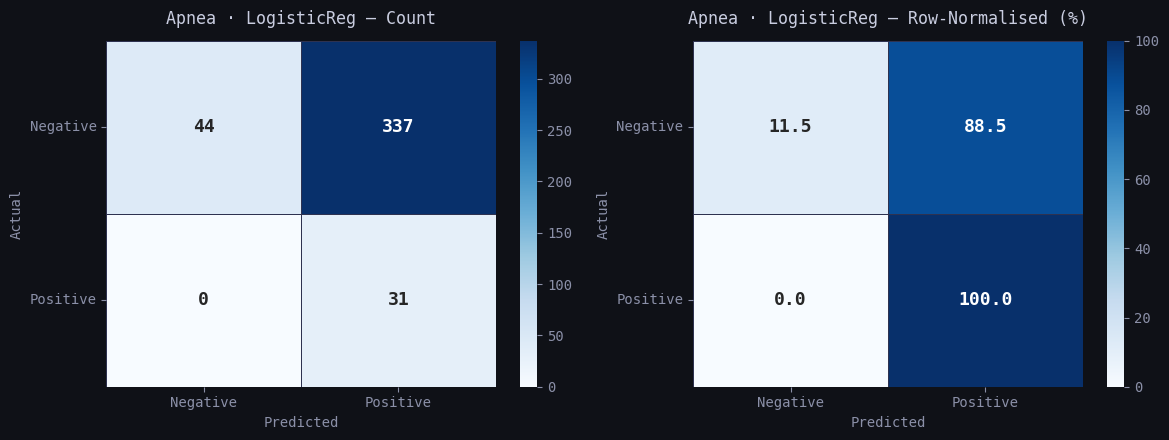

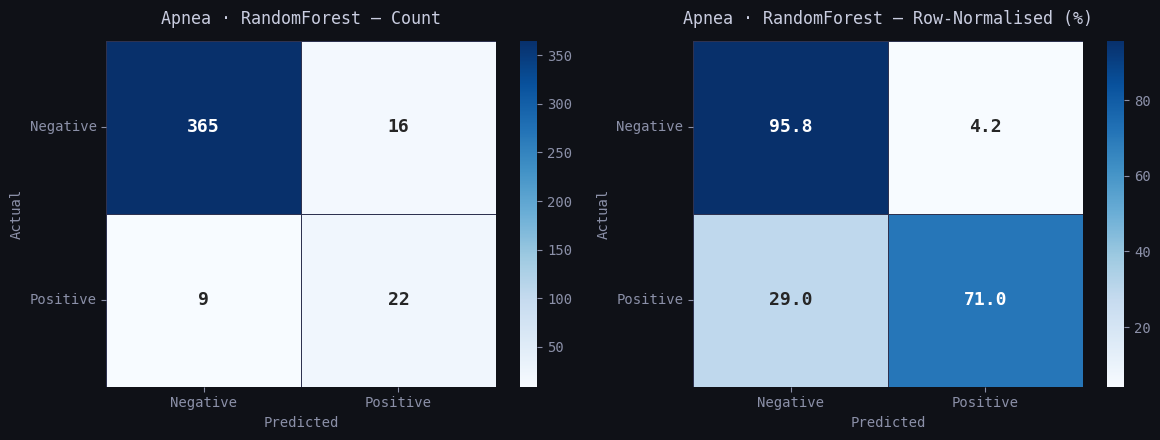

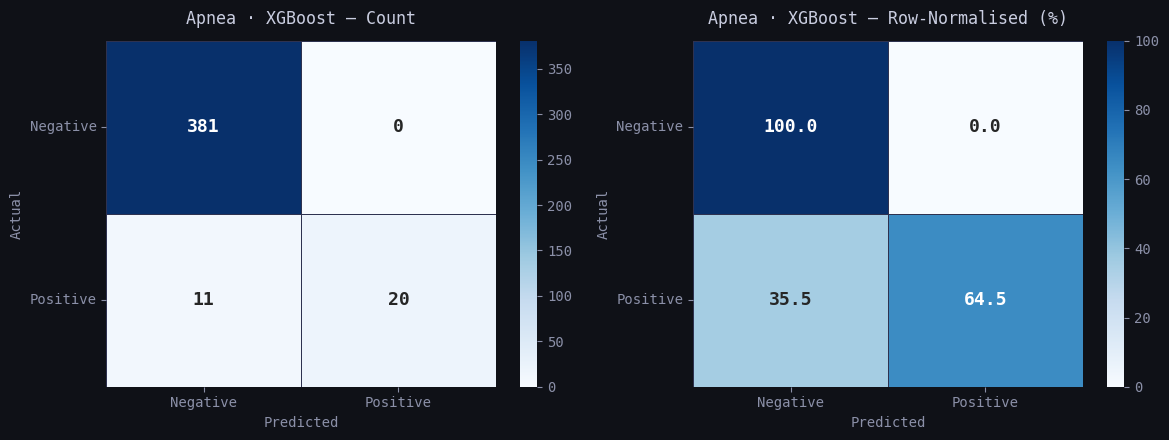

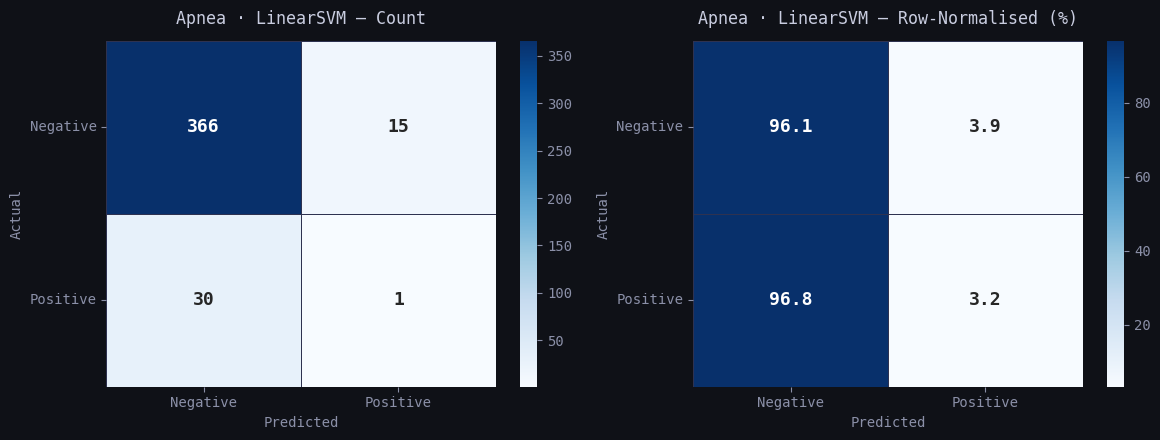

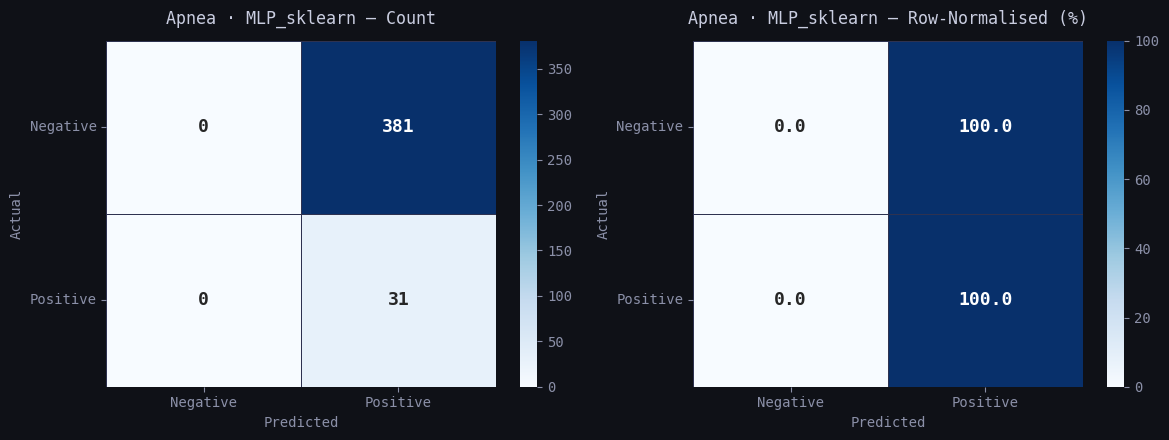

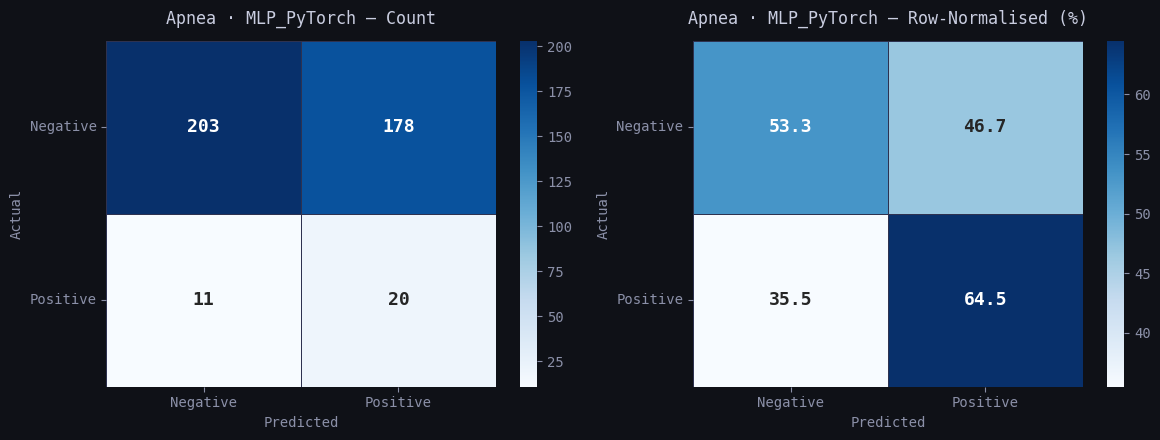

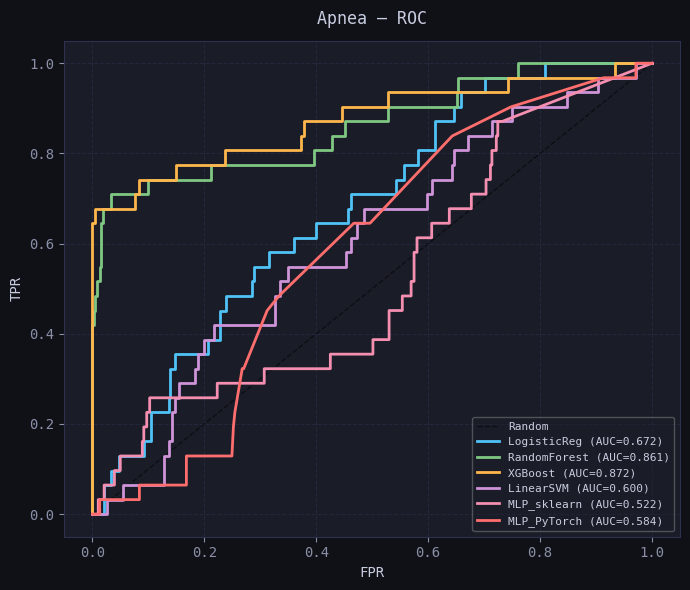

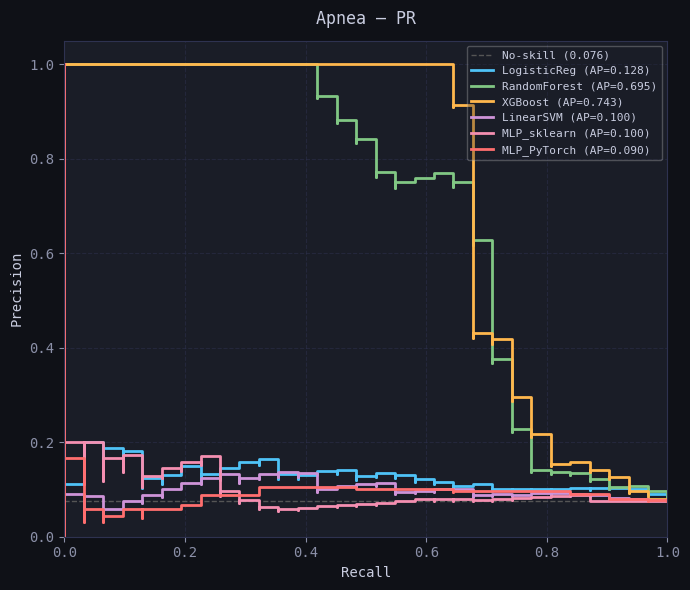


[8/8] DL Training Curves — Apnea


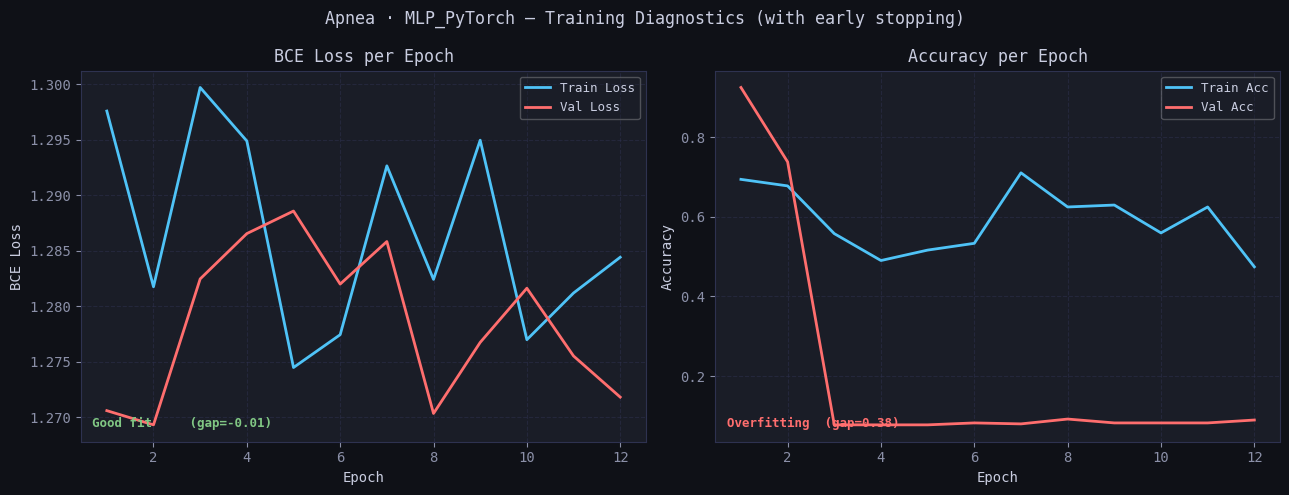


  ⏱ Apnea total: 5.4 min


  🏁 ALL DONE in 12.5 min


In [10]:
all_results = {}
overall_t0  = time.time()

for target in TARGET_COLUMNS:
    label   = TARGET_LABELS[target]
    t_start = time.time()

    print()
    print('▓' * 65)
    print(f'  🎯  {label.upper()} ({target})')
    print('▓' * 65)

    # ── Preprocessing ─────────────────────────────────────────────────────
    print('\n[1/8] Preprocessing...')
    X_pre, y, feat_names = preprocess_merged(merged, target)
    print(f'  Samples: {len(y)}  |  Pos: {y.sum()} ({y.mean()*100:.1f}%)')

    # ── Stage 1: MI pre-filter ─────────────────────────────────────────────
    print('\n[2/8] Stage 1 — MI pre-filter...')
    X_mi, feat_mi, mi_df = mi_prefilter(X_pre, y, feat_names)

    # ── Stage 2: Stability selection ──────────────────────────────────────
    print('\n[3/8] Stage 2 — Stability selection...')
    stable, freq_df = stability_selection(X_mi, y, feat_mi)
    X_final = X_mi[:, [feat_mi.index(f) for f in stable]]

    print(f'\n  FINAL feature count: {X_final.shape[1]}')
    print(f'  p/n final: {X_final.shape[1]/len(y):.3f}')
    print(f'  Top 10 most stable:')
    print(freq_df.head(10).to_string(index=False))

    # Save
    pd.Series(stable).to_csv(f'/kaggle/working/{target}_exp6b_features.csv', index=False)

    # ── Feature source breakdown ──────────────────────────────────────────
    print('\n[4/8] Feature source breakdown...')
    plot_mi_feature_sources(stable, mi_df, label)

    # ── Train / Test split ─────────────────────────────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_final, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    baseline_rate = float(y_tr.mean())
    pos_weight    = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    print(f'\n  Train={len(y_tr)} Test={len(y_te)} '
          f'pos_rate={baseline_rate:.3f} pos_weight={pos_weight:.1f}')

    # ── sklearn models ─────────────────────────────────────────────────────
    print('\n[5/8] Training sklearn models...')
    target_results = {}
    cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for mname, model in get_models(pos_weight).items():
        t0 = time.time()
        print(f'  ► {mname}...', end=' ', flush=True)
        oof  = cross_val_predict(model, X_tr, y_tr, cv=cv,
                                 method='predict_proba', n_jobs=-1)[:, 1]
        model.fit(X_tr, y_tr)
        tpr  = model.predict_proba(X_te)[:, 1]
        thr  = tune_threshold(y_tr, oof)
        pred = (tpr >= thr).astype(int)
        f1    = f1_score(y_te, pred, zero_division=0)
        auroc = roc_auc_score(y_te, tpr)
        ap    = average_precision_score(y_te, tpr)
        print(f'F1={f1:.3f}  AUROC={auroc:.3f}  AP={ap:.3f}  ({time.time()-t0:.0f}s)')
        target_results[mname] = {
            'y_true': y_te, 'probs': tpr, 'preds': pred, 'model': model
        }

    # ── PyTorch MLP ─────────────────────────────────────────────────────────
    print(f'\n  ► MLP_PyTorch (max={DL_EPOCHS} epochs, patience={DL_PATIENCE})...')
    t0 = time.time()
    dl_m, tr_l, vl_l, tr_a, vl_a = train_deep_mlp(X_tr, y_tr, X_te, y_te)
    dl_pr   = dl_proba(dl_m, X_te)
    dl_pred = (dl_pr >= tune_threshold(y_te, dl_pr)).astype(int)
    dl_f1   = f1_score(y_te, dl_pred, zero_division=0)
    dl_auc  = roc_auc_score(y_te, dl_pr)
    dl_ap   = average_precision_score(y_te, dl_pr)
    print(f'  F1={dl_f1:.3f}  AUROC={dl_auc:.3f}  AP={dl_ap:.3f}  ({time.time()-t0:.0f}s)')
    target_results['MLP_PyTorch'] = {
        'y_true': y_te, 'probs': dl_pr, 'preds': dl_pred,
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs': tr_a, 'val_accs': vl_a
    }
    all_results[target] = target_results

    # ── Classification reports ─────────────────────────────────────────────
    print(f'\n[6/8] Classification Reports — {label}')
    for mname, res in target_results.items():
        print(f'\n  ▸ {mname}')
        print(classification_report(res['y_true'], res['preds'],
              target_names=['Negative','Positive'], digits=4, zero_division=0))

    # ── Confusion matrices ─────────────────────────────────────────────────
    print(f'\n[7/8] Confusion Matrices — {label}')
    for mname, res in target_results.items():
        plot_confusion_matrices(res['y_true'], res['preds'], f'{label} · {mname}')

    plot_roc(target_results, label)
    plot_pr(target_results, label, baseline_rate)

    # ── DL curves ──────────────────────────────────────────────────────────
    print(f'\n[8/8] DL Training Curves — {label}')
    plot_dl_curves(tr_l, vl_l, tr_a, vl_a, label)

    print(f'\n  ⏱ {label} total: {(time.time()-t_start)/60:.1f} min')

print(f'\n\n  🏁 ALL DONE in {(time.time()-overall_t0)/60:.1f} min')

## 11. Global Summary

In [11]:
rows = []
for target, res_dict in all_results.items():
    for mname, res in res_dict.items():
        rows.append({
            'Target' : TARGET_LABELS[target],
            'Model'  : mname,
            'F1'     : round(f1_score(res['y_true'], res['preds'], zero_division=0), 4),
            'AUROC'  : round(roc_auc_score(res['y_true'], res['probs']), 4),
            'PR-AUC' : round(average_precision_score(res['y_true'], res['probs']), 4),
        })

summary = pd.DataFrame(rows).sort_values(['Target','F1'], ascending=[True,False])
print('\n📊  EXPERIMENT 6b — FULL RESULTS')
display(summary)
summary.to_csv('/kaggle/working/experiment6b_summary.csv', index=False)


📊  EXPERIMENT 6b — FULL RESULTS


,Target,Model,F1,AUROC,PR-AUC
14,Apnea,XGBoost,0.7843,0.8725,0.7430
13,Apnea,RandomForest,0.6377,0.8610,0.6948
17,Apnea,MLP_PyTorch,0.1747,0.5838,0.0905
12,Apnea,LogisticReg,0.1554,0.6717,0.1285
16,Apnea,MLP_sklearn,0.1400,0.5215,0.0996
15,Apnea,LinearSVM,0.0426,0.5996,0.1000
2,Insomnia,XGBoost,0.1791,0.7113,0.1883
1,Insomnia,RandomForest,0.1500,0.6792,0.1619
5,Insomnia,MLP_PyTorch,0.1318,0.5683,0.1106
3,Insomnia,LinearSVM,0.1187,0.4742,0.0612


## 12. Four-Way Comparison: Exp 4, 5, 6 (broken), 6b (fixed)


🏆  FOUR-WAY COMPARISON — BEST MODEL PER TARGET
  Target           Exp4     Exp5     Exp6    Exp6b  Verdict
------------------------------------------------------------------------------
  Apnea          0.7843   0.1825   0.7843   0.7843  ≈ Matches Exp4 (XGBoost)
  Insomnia       0.3881   0.1304   0.2128   0.1791  ✗ Exp4 still best  (Δ=-0.209 vs E4)
  RLS            0.1553   0.1818   0.1148   0.1449  ✗ Exp4 still best  (Δ=-0.010 vs E4)

  Exp4 = Questionnaire-only  |  Exp5 = PSG-only  |  Exp6 = Merged broken  |  Exp6b = Merged fixed


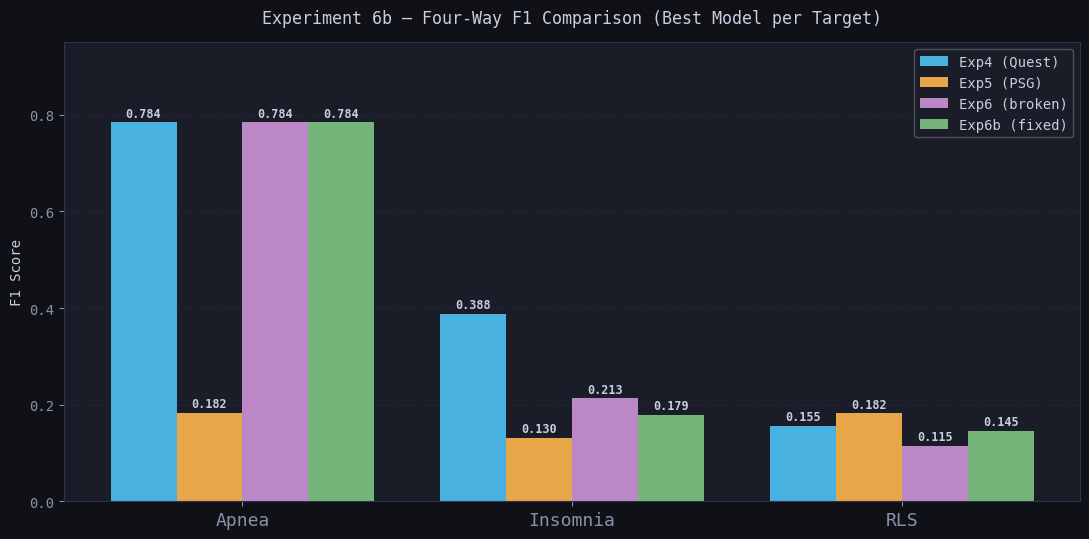

Saved: exp6b_four_way_comparison.png


In [12]:
best_6b = summary.loc[summary.groupby('Target')['F1'].idxmax()].set_index('Target')

print('\n' + '=' * 78)
print('🏆  FOUR-WAY COMPARISON — BEST MODEL PER TARGET')
print('=' * 78)
print(f'  {"Target":<12} {"Exp4":>8} {"Exp5":>8} {"Exp6":>8} {"Exp6b":>8}  Verdict')
print('-' * 78)

for lbl in ['Apnea', 'Insomnia', 'RLS']:
    e4  = BASELINES['Exp4_Questionnaire'][lbl]
    e5  = BASELINES['Exp5_PSG'][lbl]
    e6  = BASELINES['Exp6_Merged_broken'][lbl]
    e6b = best_6b.loc[lbl, 'F1'] if lbl in best_6b.index else float('nan')
    best = max(e4, e5, e6, e6b)
    m6b  = best_6b.loc[lbl, 'Model'] if lbl in best_6b.index else '?'

    if e6b > e4:
        verdict = f'✅ Merge wins! ({m6b}) +{(e6b-e4)/e4*100:.1f}% vs Exp4'
    elif abs(e6b - e4) < 0.01:
        verdict = f'≈ Matches Exp4 ({m6b})'
    else:
        verdict = f'✗ Exp4 still best  (Δ={e6b-e4:+.3f} vs E4)'

    print(f'  {lbl:<12} {e4:>8.4f} {e5:>8.4f} {e6:>8.4f} {e6b:>8.4f}  {verdict}')

print('=' * 78)
print('\n  Exp4 = Questionnaire-only  |  Exp5 = PSG-only  |  Exp6 = Merged broken  |  Exp6b = Merged fixed')

# Bar chart
targets_lbl = ['Apnea', 'Insomnia', 'RLS']
vals = {
    'Exp4 (Quest)': [BASELINES['Exp4_Questionnaire'][t] for t in targets_lbl],
    'Exp5 (PSG)':   [BASELINES['Exp5_PSG'][t]           for t in targets_lbl],
    'Exp6 (broken)':[BASELINES['Exp6_Merged_broken'][t] for t in targets_lbl],
    'Exp6b (fixed)': [best_6b.loc[t,'F1'] if t in best_6b.index else 0 for t in targets_lbl],
}
colors = ['#4fc3f7', '#ffb74d', '#ce93d8', '#81c784']

x = np.arange(len(targets_lbl))
w = 0.2
fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#0f1117')

for i, (name, vals_) in enumerate(vals.items()):
    bars = ax.bar(x + (i - 1.5) * w, vals_, w, label=name, color=colors[i], alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.006, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8.5, color='#c9cde0', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(targets_lbl, fontsize=13)
ax.set_ylabel('F1 Score')
ax.set_title('Experiment 6b — Four-Way F1 Comparison (Best Model per Target)', pad=14)
ax.legend(fontsize=10, framealpha=0.3)
ax.set_ylim(0, 0.95)
ax.grid(True, axis='y', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/kaggle/working/exp6b_four_way_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: exp6b_four_way_comparison.png')